# AKI-Kohorte: Schweregrad-Scores & Interventionen-Timing

Kernnotebook für die Präsentation **„Critical Decisions in the ICU“**: AKI-Kohorte (10.485), Interventionen (Flüssigkeiten, Diuretika, Vasopressoren, Dialyse), Mortalität, Timing, SOFA/SAPS II, Chi², logistische Regression.

## Scores & Time Windows

| Score | Time Window | Source | Relevant For |
|-------|-------------|--------|--------------|
| **SOFA total** | First 24h | `mimiciii_derived.sofa` via `add_sofa_score()` | General ICU severity, case-mix |
| **SOFA renal** | First 24h | `mimiciii_derived.sofa` via `add_sofa_score()` | AKI organ-specific severity |
| **SAPS II** | First 24h | `mimiciii_derived.sapsii` via `add_sapsii_score()` | Mortality prediction, case-mix |
| **KDIGO (aki_stage)** | First 24h | Creatinine-based, computed in-notebook | AKI staging |

All scores are derived from the **first 24 hours** of the ICU stay (MIMIC-III first-day definition). When stratifying by intervention timing (e.g. vasopressor early vs. late), the 24h score window may overlap with the intervention period.

For shorter baseline windows (e.g. first 6h before any intervention) use `compute_sofa_from_raw(window_hours=6)` from `src/utils.py`.

—

## 1. Setup

## 2. Kohorte laden und anreichern
AKI-Kohorte aus `derived.mv_aki_icu_first_cohort`, SOFA/SAPS II, Dialyse-, Vasopressor-, Beatmungs- und Timing-Flags.

In [80]:
# Projektwurzel = report_abgabe (dieses Notebook liegt in report_abgabe/nieren)
import sys
import importlib.util
from pathlib import Path

_start = Path.cwd().resolve()
_candidates = []
for _p in [_start] + list(_start.parents):
    if (_p / "src" / "cohort.py").exists():
        _candidates.append(_p)
if not _candidates and (_start / "report_abgabe" / "src" / "cohort.py").exists():
    _candidates.append(_start / "report_abgabe")
if not _candidates and (_start / "mimiciii-BioMedicalProject" / "report_abgabe" / "src" / "cohort.py").exists():
    _candidates.append(_start / "mimiciii-BioMedicalProject" / "report_abgabe")

_project_root = None
for _p in _candidates:
    if _p.name == "report_abgabe" or (_p / "nieren").is_dir():
        _project_root = _p
        break
if _project_root is None and _candidates:
    _project_root = _candidates[0]
if _project_root is None:
    raise FileNotFoundError("src/cohort.py nicht gefunden. Ordner 'report_abgabe' öffnen oder CWD auf report_abgabe setzen.")

_project_root = _project_root.resolve()
_sp = str(_project_root)
# Nur report_abgabe als Quelle für "src": andere Einträge mit src/cohort.py (z. B. Hauptprojekt) raus
sys.path = [_sp] + [p for p in sys.path if p != _sp and not (Path(p).resolve() / "src" / "cohort.py").exists()]
# Gecachtes "src" entfernen, damit neu von report_abgabe geladen wird
for _k in list(sys.modules.keys()):
    if _k == "src" or _k.startswith("src."):
        del sys.modules[_k]

# Paket "src" anlegen, damit "from src.db import q" in cohort/utils funktioniert
import types
_src = types.ModuleType("src")
_src.__path__ = [str(_project_root / "src")]
sys.modules["src"] = _src

def _load_src_module(name: str):
    path = _project_root / "src" / f"{name}.py"
    spec = importlib.util.spec_from_file_location(f"src.{name}", path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f"src.{name}"] = mod
    setattr(sys.modules["src"], name, mod)
    spec.loader.exec_module(mod)
    return mod

_load_src_module("db")
_load_src_module("cohort")
_load_src_module("utils")
from src.cohort import load_aki_cohort
from src.utils import (
    add_icu_los_days,
    add_dialysis_flag,
    add_early_dopamine_flag,
    add_sofa_score,
    add_sapsii_score,
    add_vasopressor_flags,
    add_mechanical_ventilation_flag,
    add_early_late_dialysis_flags,
    extract_dialysis_timing,              # falls in src.utils vorhanden
    add_dialysis_near_icu_discharge_flag,
    recode_ethnicity,
    add_rrt_persistence_near_discharge,
)

# 1) Load cohort
df_aki = load_aki_cohort()

# 2) Ensure time columns are datetime (super wichtig!)
for c in ["intime", "outtime", "admittime", "dischtime", "deathtime"]:
    if c in df_aki.columns:
        df_aki[c] = df_aki[c].astype("datetime64[ns]")

# 3) Add baseline / outcomes
df_aki = add_icu_los_days(df_aki)

# 4) Dialysis "ever" flag (pragmatic; ICD + MV)
df_aki = add_dialysis_flag(df_aki)

# 5) SOFA + interventions
df_aki = add_sofa_score(df_aki)
df_aki = add_sapsii_score(df_aki)
df_aki = add_mechanical_ventilation_flag(df_aki)

# 6) Vasopressors / dopamine early flags
df_aki = add_vasopressor_flags(df_aki, window_hours=24)
df_aki = add_early_dopamine_flag(df_aki, window_hours=24)

# 7) Ethnicity grouping
df_aki = recode_ethnicity(df_aki)   # sollte eine neue Spalte wie ethnicity_grp erzeugen

# 8) Timing-aware dialysis (nur MV Events)
df_aki = add_early_late_dialysis_flags(
    df_aki,
    window_hours=24,
    include_inputevents=True,
    allow_negative_hours=False
)

# 9) Optional: Dialysis start/end/duration (falls du die Funktion hast)
# df_aki = extract_dialysis_timing(df_aki)

# 10) Dialysis near ICU discharge (last 6h)
df_aki = add_dialysis_near_icu_discharge_flag(
    df_aki,
    hours_before_discharge=6,
    include_inputevents=True
)
df_aki = extract_dialysis_timing(df_aki)
df_aki = add_rrt_persistence_near_discharge(
    df_aki,
    hours_before_discharge=6
) 

# 11) Quick sanity checks
print("Rows:", len(df_aki))


Rows: 10485


In [81]:
# (entfernt: Interventionstabelle, nicht für Präsentationsfolie)


In [82]:
from src.utils import (
    add_early_fluid_flag,
    add_early_diuretic_flag,
)

WINDOW_HOURS = 24  # <- hier anpassen (z.B. 6, 12, 24, 48)

df = df_aki.copy()
df = add_early_fluid_flag(df, window_hours=WINDOW_HOURS)
df = add_early_diuretic_flag(df, window_hours=WINDOW_HOURS)


In [83]:
import matplotlib.pyplot as plt
import numpy as np

def plot_interventions(df, cols, title="Interventions", figsize=(9, 5)):
    """Horizontal bar chart: Anteil (n) pro Intervention (0/1)."""
    out = []
    for c in cols:
        if c not in df.columns:
            continue
        x = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
        out.append({"variable": c.replace("_", " ").title(), "n": int(x.sum()), "pct": 100 * x.mean()})
    plot_df = pd.DataFrame(out).sort_values("pct", ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["pct"], color="steelblue", alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["variable"])
    ax.set_xlabel("Anteil (%)")
    ax.set_title(title)
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["pct"] + 0.5, i, f"n={row['n']}", va="center", fontsize=9)
    plt.tight_layout()
    return fig

### Balkendiagramm: Interventionen in der AKI-Kohorte

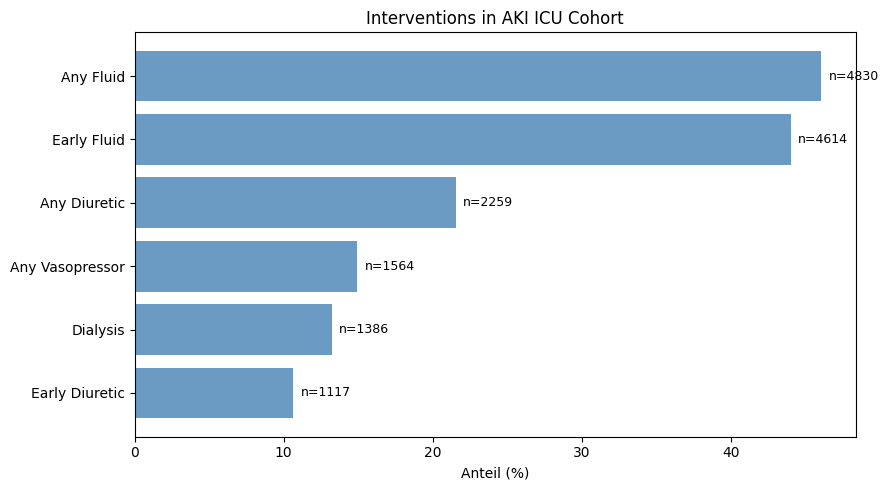

In [84]:
cols = [
    "dialysis",
    "any_vasopressor",
    "early_fluid",
    "any_fluid",
    "early_diuretic",
    "any_diuretic",
]

fig = plot_interventions(
    df,
    cols,
    title="Interventions in AKI ICU Cohort"
)
plt.show()


### Hospital Mortality by Intervention Status

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_intervention(
    df,
    interventions,
    mortality_col="hospital_mortality",
    figsize=(9, 5),
    title="Hospital Mortality by Intervention Status"
):
    rows = []

    for c in interventions:
        if c not in df.columns:
            continue

        for val, label in [(1, "Yes"), (0, "No")]:
            sub = df[df[c] == val]
            if len(sub) == 0:
                continue

            mort = pd.to_numeric(sub[mortality_col], errors="coerce")
            rows.append({
                "Intervention": c.replace("_", " ").title(),
                "Group": label,
                "Mortality": 100 * mort.mean(),
                "N": len(sub),
            })

    plot_df = pd.DataFrame(rows)

    # Order by mortality in YES group
    order = (
        plot_df[plot_df["Group"] == "Yes"]
        .sort_values("Mortality")["Intervention"]
    )

    fig, ax = plt.subplots(figsize=figsize)

    y = np.arange(len(order))
    width = 0.35

    yes = plot_df[plot_df["Group"] == "Yes"].set_index("Intervention").loc[order]
    no  = plot_df[plot_df["Group"] == "No"].set_index("Intervention").loc[order]

    ax.barh(y - width/2, no["Mortality"], height=width, label="No")
    ax.barh(y + width/2, yes["Mortality"], height=width, label="Yes")

    # --- Labels: % and n
    for i, name in enumerate(order):
        ax.text(
            no.loc[name, "Mortality"] + 0.6,
            i - width/2,
            f'{no.loc[name, "Mortality"]:.1f}%  (n={no.loc[name, "N"]})',
            va="center",
            fontsize=10
        )
        ax.text(
            yes.loc[name, "Mortality"] + 0.6,
            i + width/2,
            f'{yes.loc[name, "Mortality"]:.1f}%  (n={yes.loc[name, "N"]})',
            va="center",
            fontsize=10
        )

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=11)
    ax.set_xlabel("Hospital Mortality (%)", fontsize=12)
    ax.set_title(title, fontsize=14)

    ax.legend(frameon=False)
    ax.set_xlim(0, max(plot_df["Mortality"]) * 1.25)

    plt.tight_layout()
    return fig


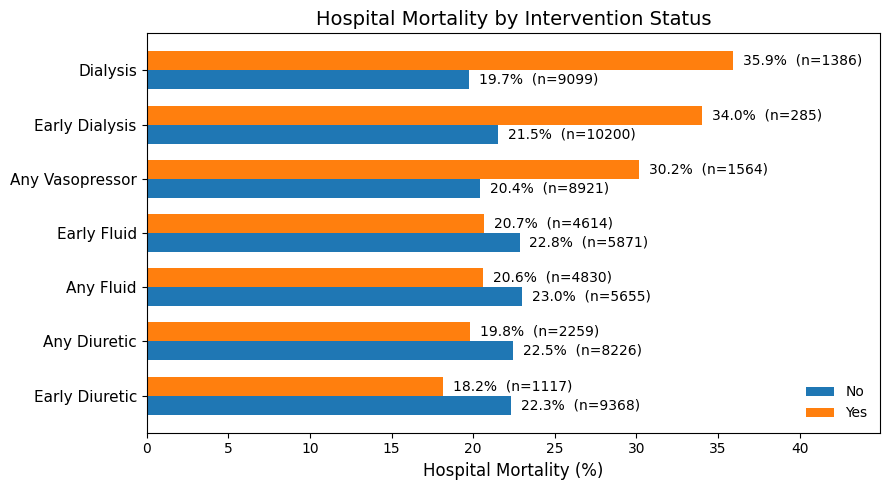

In [86]:
interventions = [
    "dialysis",
    "early_dialysis",
    "any_vasopressor",
    "early_vasopressor",
    "any_fluid",
    "early_fluid",
    "any_diuretic",
    "early_diuretic",

]

fig = plot_mortality_by_intervention(
    df,
    interventions,
    mortality_col="hospital_mortality",
    title="Hospital Mortality by Intervention Status"
)

plt.show()


In [87]:
import pandas as pd
import numpy as np
from src.db import q

def first_intervention_timing(
    df,
    patterns,
    label,
):
    """
    Adds two columns:
      - first_<label>_hours
      - first_<label>_timing  ∈ {0–12 h, 12–24 h, >24 h, No intervention}
    """

    where = " OR ".join([f"LOWER(di.label) LIKE '{p}'" for p in patterns])

    ev = q(f"""
        SELECT ie.icustay_id, ie.starttime
        FROM inputevents_mv ie
        JOIN d_items di ON ie.itemid = di.itemid
        WHERE {where}
    """)

    ev = ev.merge(
        df[["icustay_id", "intime"]],
        on="icustay_id",
        how="inner"
    ).dropna(subset=["starttime", "intime"])

    ev["hours_since_icu"] = (
        ev["starttime"] - ev["intime"]
    ).dt.total_seconds() / 3600

    ev = ev[ev["hours_since_icu"] >= 0]

    first_ev = (
        ev.sort_values(["icustay_id", "hours_since_icu"])
          .groupby("icustay_id", as_index=False)
          .first()[["icustay_id", "hours_since_icu"]]
    )

    out = df.merge(first_ev, on="icustay_id", how="left")

    timing_col = f"first_{label}_timing"
    hours_col = f"first_{label}_hours"

    out[hours_col] = out["hours_since_icu"]

    out[timing_col] = np.select(
        [
            out[hours_col].between(0, 12, inclusive="left"),
            out[hours_col].between(12, 24, inclusive="left"),
            out[hours_col] > 24,
            out[hours_col].isna(),
        ],
        [
            "0–12 h",
            "12–24 h",
            ">24 h",
            "No intervention",
        ],
        default="Other",
    )

    out[timing_col] = pd.Categorical(
        out[timing_col],
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

    return out.drop(columns=["hours_since_icu"])


In [88]:
VASO_PATTERNS = [
    "%norepinephrine%", "%epinephrine%",
    "%phenylephrine%", "%vasopressin%",
]

FLUID_PATTERNS = [
    "%normal saline%", "%0.9%saline%", "%saline%",
    "%lactated ring%", "%ringer%",
    "%plasmalyte%", "%plasma-lyte%",
    "%d5w%", "%dextrose%",
    "%albumin%",
    "%packed red%", "%prbc%", "%red blood cell%",
    "%fresh frozen plasma%", "%ffp%",
    "%platelet%",
]

DIURETIC_PATTERNS = [
    "%furosemide%", "%lasix%",
    "%bumetanide%", "%torsemide%",
    "%chlorothiazide%", "%metolazone%",
    "%mannitol%", "%acetazolamide%",
]


In [89]:
df3 = df.copy()

df3 = first_intervention_timing(df3, VASO_PATTERNS, "vaso")
df3 = first_intervention_timing(df3, FLUID_PATTERNS, "fluid")
df3 = first_intervention_timing(df3, DIURETIC_PATTERNS, "diuretic")


In [90]:
def mortality_by_timing(df, timing_col, mortality_col="hospital_mortality"):
    out = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mortality_pct=(mortality_col, "mean"),
        )
        .reset_index()
    )
    out["mortality_pct"] *= 100
    return out


In [91]:
# (entfernt: nur Print mort_vaso/fluid/diur, nicht für Folie)


In [92]:
import matplotlib.pyplot as plt

def plot_combined_mortality_by_timing(
    df,
    timing_cols,
    titles,
    mortality_col="hospital_mortality",
    figsize=(12, 4),
):
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    for ax, timing_col, title in zip(axes, timing_cols, titles):
        tmp = (
            df
            .groupby(timing_col)
            .agg(
                n=(mortality_col, "size"),
                mort=(mortality_col, "mean"),
            )
            .reindex(order)
            .reset_index()
        )

        tmp["mort"] *= 100

        ax.bar(
            tmp[timing_col],
            tmp["mort"]
        )

        for i, row in tmp.iterrows():
            if pd.isna(row["mort"]):
                continue
            ax.text(
                i,
                row["mort"] + 0.8,
                f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
                ha="center",
                va="bottom",
                fontsize=11
            )

        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Timing of first intervention", fontsize=11)
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)

    axes[0].set_ylabel("Hospital Mortality (%)", fontsize=12)
    axes[0].set_ylim(0, df[mortality_col].mean() * 200)

    fig.suptitle(
        "Hospital Mortality by Timing of First Intervention",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


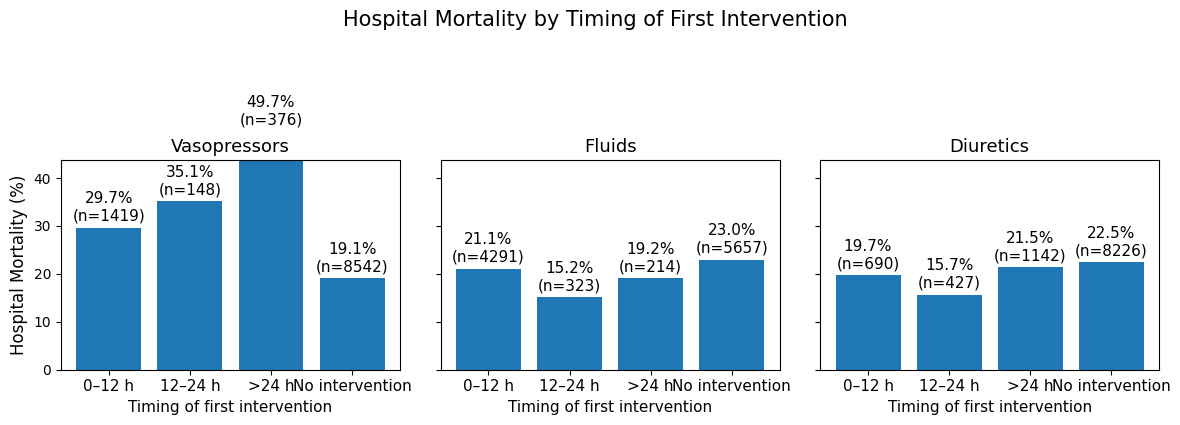

In [93]:
fig = plot_combined_mortality_by_timing(
    df3,
    timing_cols=[
        "first_vaso_timing",
        "first_fluid_timing",
        "first_diuretic_timing",
    ],
    titles=[
        "Vasopressors",
        "Fluids",
        "Diuretics",
    ],
)

plt.show()


In [94]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_mortality_by_timing_single(
    df,
    timing_col,
    title,
    mortality_col="hospital_mortality",
    colors=None,
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    if colors is None:
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mort=(mortality_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["mort"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mort"],
        color=colors
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mort"]):
            continue
        ax.text(
            i,
            row["mort"] + 0.8,
            f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_ylabel("Hospital Mortality (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.set_title(title, fontsize=14)

    ax.set_ylim(0, max(tmp["mort"].max() * 1.25, 5))
    ax.tick_params(axis="x", labelsize=11)

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


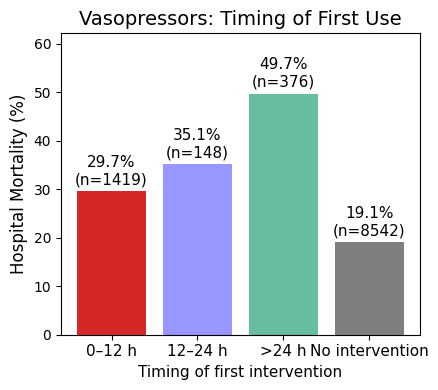

In [95]:
fig_vaso = plot_mortality_by_timing_single(
    df3,
    timing_col="first_vaso_timing",
    title="Vasopressors: Timing of First Use",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


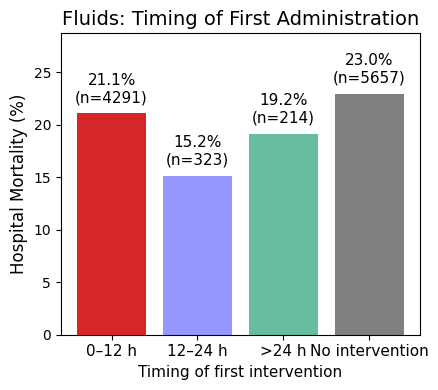

In [96]:
fig_fluid = plot_mortality_by_timing_single(
    df3,
    timing_col="first_fluid_timing",
    title="Fluids: Timing of First Administration",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


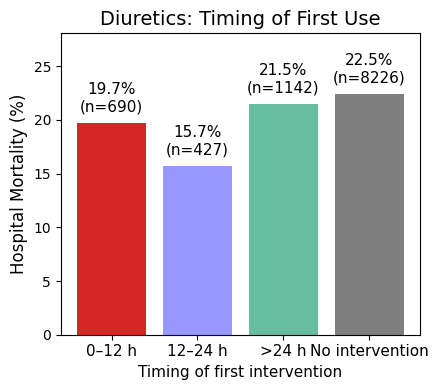

In [97]:
fig_diur = plot_mortality_by_timing_single(
    df3,
    timing_col="first_diuretic_timing",
    title="Diuretics: Timing of First Use",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
    
)

plt.show()


In [98]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rrt_persistence_by_timing_single(
    df,
    timing_col,
    title,
    outcome_col="rrt_persistent_last6h",
    colors=None,
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    if colors is None:
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(outcome_col, "size"),
            rate=(outcome_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["rate"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["rate"],
        color=colors
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["rate"]):
            continue
        ax.text(
            i,
            row["rate"] + 0.8,
            f'{row["rate"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_ylabel("Persistent RRT at ICU Discharge (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.set_title(title, fontsize=14)

    ax.set_ylim(0, max(tmp["rate"].max() * 1.25, 5))
    ax.tick_params(axis="x", labelsize=11)

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


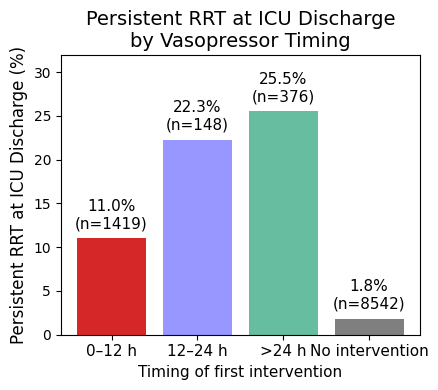

In [99]:
fig_vaso_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_vaso_timing",
    title="Persistent RRT at ICU Discharge\nby Vasopressor Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


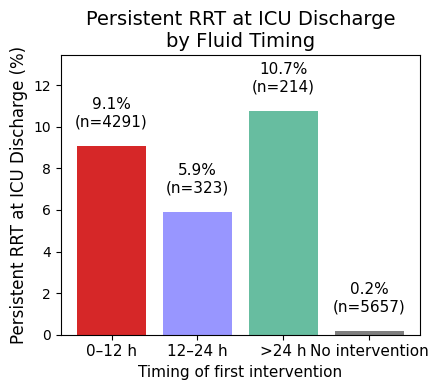

In [100]:
fig_fluid_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_fluid_timing",
    title="Persistent RRT at ICU Discharge\nby Fluid Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


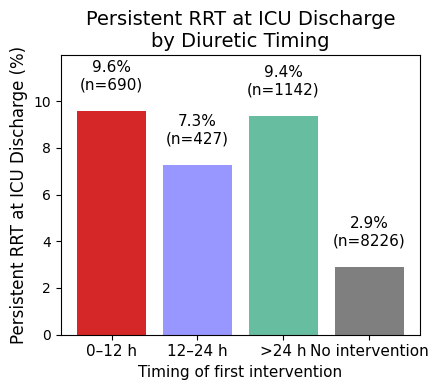

In [101]:
fig_diur_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_diuretic_timing",
    title="Persistent RRT at ICU Discharge\nby Diuretic Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


In [102]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_score_by_timing(
    df,
    timing_col,
    score_col,
    title,
    ylabel,
    color="#1f77b4",
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            mean_score=(score_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mean_score"],
        color=color,
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mean_score"]):
            continue
        ax.text(
            i,
            row["mean_score"] + 0.5,
            f'{row["mean_score"]:.1f}\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.tick_params(axis="x", labelsize=11)

    ax.set_ylim(0, max(tmp["mean_score"].max() * 1.25, 3))
    plt.tight_layout()
    return fig

In [103]:
def plot_mortality_by_timing(
    df,
    timing_col,
    title,
    mortality_col="hospital_mortality",
    color="#d62728",
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mort=(mortality_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["mort"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mort"],
        color=color,
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mort"]):
            continue
        ax.text(
            i,
            row["mort"] + 0.8,
            f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Hospital Mortality (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.tick_params(axis="x", labelsize=11)

    ax.set_ylim(0, max(tmp["mort"].max() * 1.25, 5))
    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\989561893.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\989561893.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\989561893.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData

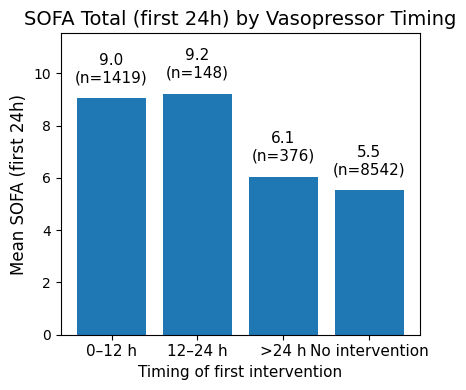

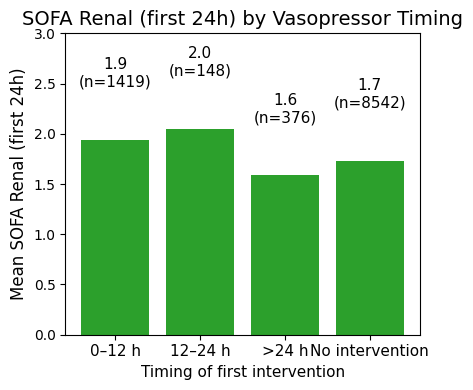

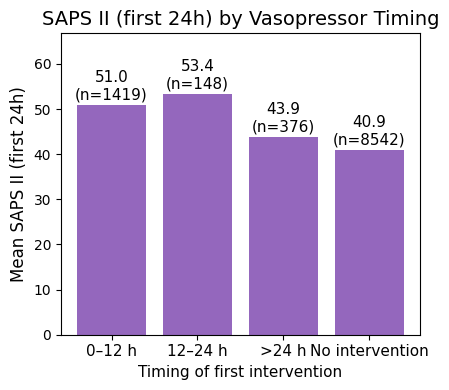

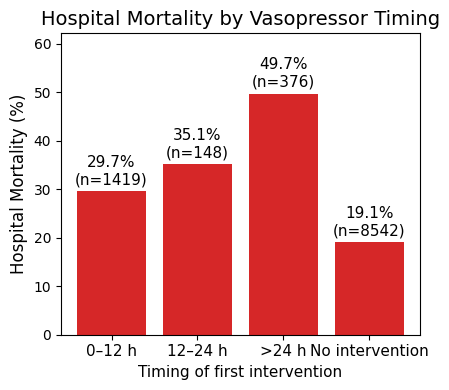

In [104]:
fig_sofa_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sofa",
    title="SOFA Total (first 24h) by Vasopressor Timing",
    ylabel="Mean SOFA (first 24h)",
    color="#1f77b4",
)

fig_sofa_renal_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) by Vasopressor Timing",
    ylabel="Mean SOFA Renal (first 24h)",
    color="#2ca02c",
)

fig_saps_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) by Vasopressor Timing",
    ylabel="Mean SAPS II (first 24h)",
    color="#9467bd",
)

fig_mort_vaso = plot_mortality_by_timing(
    df3,
    "first_vaso_timing",
    title="Hospital Mortality by Vasopressor Timing",
)

plt.show()


In [105]:
import pandas as pd
import numpy as np

def add_score_bins(df, score_col, n_bins=4, prefix=None):
    out = df.copy()
    if prefix is None:
        prefix = score_col
    out[f"{prefix}_bin"] = pd.qcut(out[score_col], q=n_bins, duplicates="drop")
    return out

def hours_to_timing_group(hours_series):
    return pd.Categorical(
        np.select(
            [
                hours_series.between(0, 12, inclusive="left"),
                hours_series.between(12, 24, inclusive="left"),
                hours_series > 24,
                hours_series.isna(),
            ],
            ["0–12 h", "12–24 h", ">24 h", "No intervention"],
            default="Other",
        ),
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

# df4: df3 + Timing-Gruppen + Score-Bins (für score_group_timing_stats)
df4 = df3.copy()
df4["vaso_timing"] = hours_to_timing_group(df4.get("first_vaso_hours", np.nan))
df4["fluid_timing"] = hours_to_timing_group(df4.get("first_fluid_hours", np.nan))
df4["diuretic_timing"] = hours_to_timing_group(df4.get("first_diuretic_hours", np.nan))
df4 = add_score_bins(df4, "sofa", n_bins=4, prefix="sofa")
df4 = add_score_bins(df4, "sofa_renal", n_bins=4, prefix="sofa_renal")
df4 = add_score_bins(df4, "sapsii", n_bins=4, prefix="sapsii")

In [106]:
import pandas as pd
import numpy as np

def add_score_bins(df, score_col, n_bins=4, prefix=None):
    out = df.copy()
    if prefix is None:
        prefix = score_col
    out[f"{prefix}_bin"] = pd.qcut(out[score_col], q=n_bins, duplicates="drop")
    return out

def hours_to_timing_group(hours_series):
    return pd.Categorical(
        np.select(
            [
                hours_series.between(0, 12, inclusive="left"),
                hours_series.between(12, 24, inclusive="left"),
                hours_series > 24,
                hours_series.isna(),
            ],
            ["0–12 h", "12–24 h", ">24 h", "No intervention"],
            default="Other",
        ),
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

# df4 für Stats: df3 + Timing-Gruppen + Score-Bins
df4 = df3.copy()
df4["vaso_timing"] = hours_to_timing_group(df4.get("first_vaso_hours", np.nan))
df4["fluid_timing"] = hours_to_timing_group(df4.get("first_fluid_hours", np.nan))
df4["diuretic_timing"] = hours_to_timing_group(df4.get("first_diuretic_hours", np.nan))
df4 = add_score_bins(df4, "sofa", n_bins=4, prefix="sofa")
df4 = add_score_bins(df4, "sofa_renal", n_bins=4, prefix="sofa_renal")
df4 = add_score_bins(df4, "sapsii", n_bins=4, prefix="sapsii")

def score_group_timing_stats(df, score_bin_col, timing_col, outcome_col="hospital_mortality"):
    # n und mortality pro Bin×Timing
    agg = (
        df.groupby([score_bin_col, timing_col])
          .agg(n=("icustay_id", "size"),
               mortality=(outcome_col, "mean"))
          .reset_index()
    )
    agg["mortality_pct"] = agg["mortality"] * 100

    # Timing-Verteilung innerhalb jedes Score-Bins
    agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")
    agg["within_bin_pct"] = 100 * agg["n"] / agg["bin_total"]
    return agg

stats_sofa_vaso = score_group_timing_stats(df4, "sofa_bin", "vaso_timing")
stats_sofa_fluid = score_group_timing_stats(df4, "sofa_bin", "fluid_timing")
stats_sofa_diur = score_group_timing_stats(df4, "sofa_bin", "diuretic_timing")

stats_sofa_vaso.head()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default an

,sofa_bin,vaso_timing,n,mortality,mortality_pct,bin_total,within_bin_pct
0,"(-0.001, 3.0]",0–12 h,76,0.105263,10.526316,2870,2.648084
1,"(-0.001, 3.0]",12–24 h,6,0.000000,0.000000,2870,0.209059
2,"(-0.001, 3.0]",>24 h,101,0.415842,41.584158,2870,3.519164
3,"(-0.001, 3.0]",No intervention,2687,0.086342,8.634164,2870,93.623693
4,"(3.0, 5.0]",0–12 h,183,0.131148,13.114754,2449,7.472438


In [107]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_timing_within_score_bins(stats_df, score_bin_col, timing_col, title, figsize=(10, 4.5)):
    order_timing = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    bins = list(stats_df[score_bin_col].dropna().unique())
    bins = sorted(bins, key=lambda x: str(x))

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(bins))
    width = 0.2
    offsets = {"0–12 h": -1.5*width, "12–24 h": -0.5*width, ">24 h": 0.5*width, "No intervention": 1.5*width}

    for t in order_timing:
        sub = stats_df[stats_df[timing_col] == t].set_index(score_bin_col).reindex(bins)
        y = sub["mortality_pct"].values
        n = sub["n"].fillna(0).astype(int).values

        ax.bar(x + offsets[t], y, width, label=t)

        for i in range(len(bins)):
            if np.isnan(y[i]):
                continue
            # ax.text(x[i] + offsets[t], y[i] + 0.6, f"n={n[i]}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    labels = []
    for b in bins:
        n_bin = stats_df.loc[stats_df[score_bin_col] == b, "n"].sum()
        labels.append(f"{b}\n(n={int(n_bin)})")

    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_ylabel("Hospital mortality (%)", fontsize=12)
    ax.set_xlabel("Score group (quantiles)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, ncol=4)
    ax.set_ylim(0, max(stats_df["mortality_pct"].max() * 1.25, 5))

    plt.tight_layout()
    return fig


In [108]:
import pandas as pd
import numpy as np

def add_score_bins(df, score_col, n_bins=4, prefix=None):
    out = df.copy()
    if prefix is None:
        prefix = score_col
    out[f"{prefix}_bin"] = pd.qcut(out[score_col], q=n_bins, duplicates="drop")
    return out

def hours_to_timing_group(hours_series):
    return pd.Categorical(
        np.select(
            [
                hours_series.between(0, 12, inclusive="left"),
                hours_series.between(12, 24, inclusive="left"),
                hours_series > 24,
                hours_series.isna(),
            ],
            ["0–12 h", "12–24 h", ">24 h", "No intervention"],
            default="Other",
        ),
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

# df4: df3 + Timing-Gruppen (vaso/fluid/diuretic) + Score-Bins (SOFA, SOFA renal, SAPS II)
df4 = df3.copy()
df4["vaso_timing"] = hours_to_timing_group(df4.get("first_vaso_hours", np.nan))
df4["fluid_timing"] = hours_to_timing_group(df4.get("first_fluid_hours", np.nan))
df4["diuretic_timing"] = hours_to_timing_group(df4.get("first_diuretic_hours", np.nan))

df4 = add_score_bins(df4, "sofa", n_bins=4, prefix="sofa")
df4 = add_score_bins(df4, "sofa_renal", n_bins=4, prefix="sofa_renal")
df4 = add_score_bins(df4, "sapsii", n_bins=4, prefix="sapsii")

In [109]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_timing_within_score_bins(
    stats_df, score_bin_col, timing_col, title, figsize=(10, 4.5)
):
    order_timing = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    bins = list(stats_df[score_bin_col].dropna().unique())
    bins = sorted(bins, key=lambda x: str(x))

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(bins))
    width = 0.2
    offsets = {
        "0–12 h": -1.5 * width,
        "12–24 h": -0.5 * width,
        ">24 h": 0.5 * width,
        "No intervention": 1.5 * width,
    }

    for t in order_timing:
        sub = (
            stats_df[stats_df[timing_col] == t]
            .set_index(score_bin_col)
            .reindex(bins)
        )

        y = sub["mortality_pct"].values
        n = sub["n"].fillna(0).astype(int).values

        # Binomial standard error (in %)
        se = np.full_like(y, np.nan, dtype=float)
        valid = n > 0
        p = y[valid] / 100.0
        se[valid] = np.sqrt(p * (1 - p) / n[valid]) * 100

        ax.bar(
            x + offsets[t],
            y,
            width,
            label=t,
            yerr=se,
            capsize=3,
            error_kw=dict(lw=1, capthick=1),
        )

    ax.set_xticks(x)
    labels = []
    for b in bins:
        n_bin = stats_df.loc[stats_df[score_bin_col] == b, "n"].sum()
        labels.append(f"{b}\n(n={int(n_bin)})")

    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Hospital mortality (%)", fontsize=12)
    ax.set_xlabel("Score group (quantiles)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, ncol=4)
    ax.set_ylim(0, max(stats_df["mortality_pct"].max() * 1.25, 5))

    plt.tight_layout()
    return fig


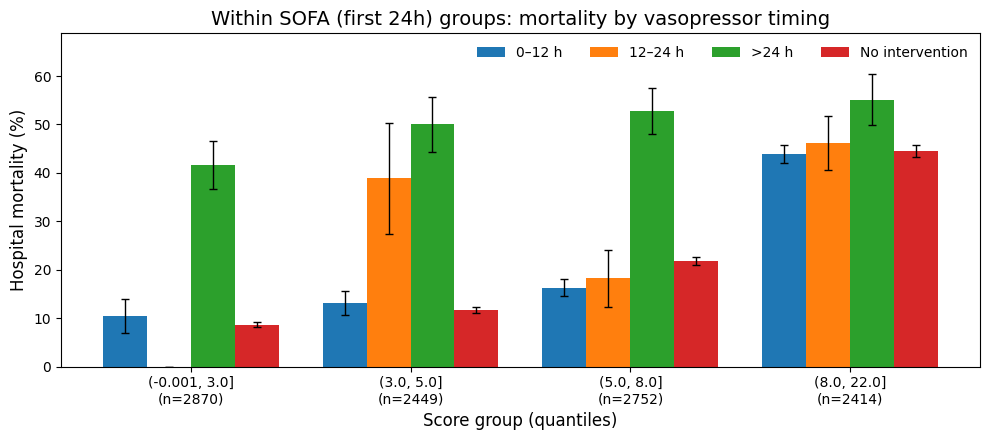

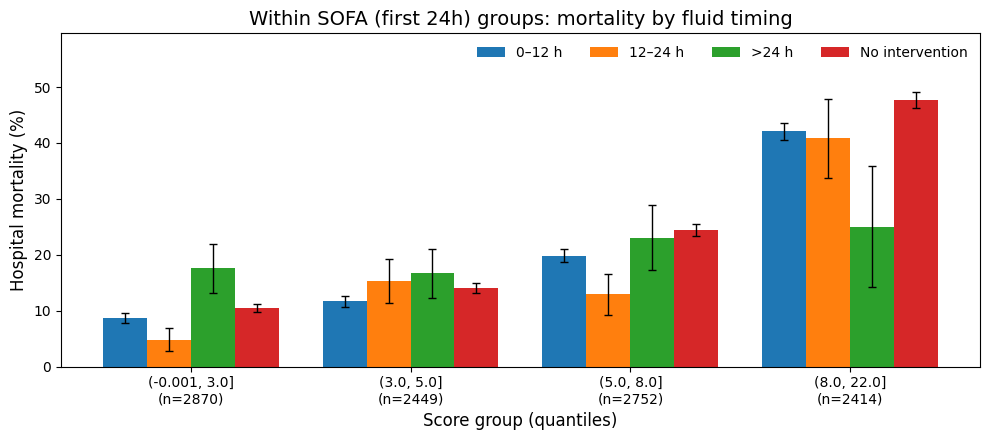

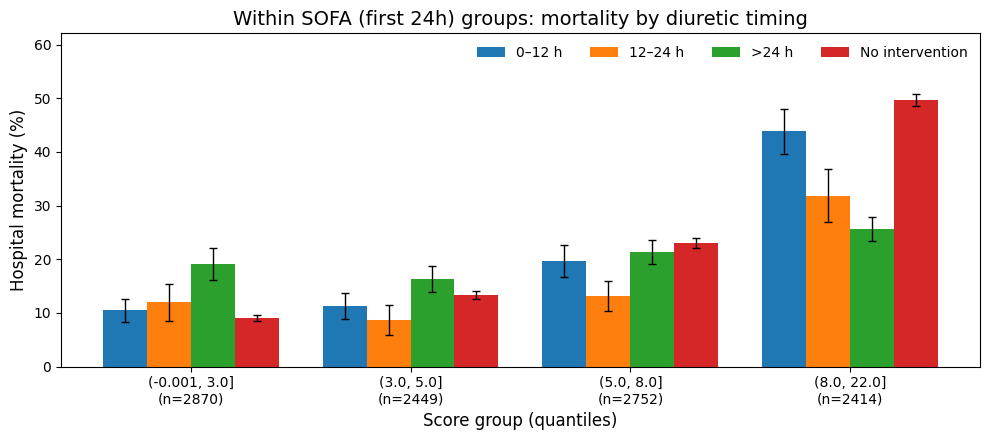

In [110]:
fig1 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_vaso,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    title="Within SOFA (first 24h) groups: mortality by vasopressor timing"
)
plt.show()

fig2 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_fluid,
    score_bin_col="sofa_bin",
    timing_col="fluid_timing",
    title="Within SOFA (first 24h) groups: mortality by fluid timing"
)
plt.show()

fig3 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_diur,
    score_bin_col="sofa_bin",
    timing_col="diuretic_timing",
    title="Within SOFA (first 24h) groups: mortality by diuretic timing"
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


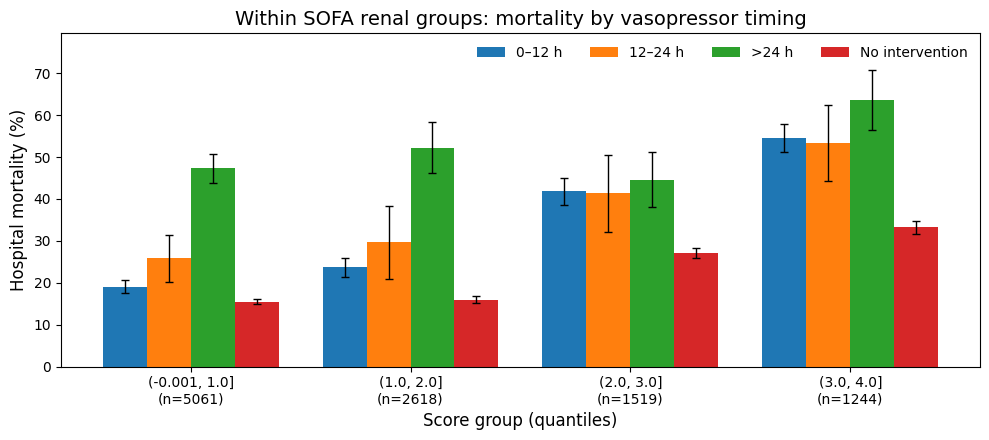

C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_26696\2895930816.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


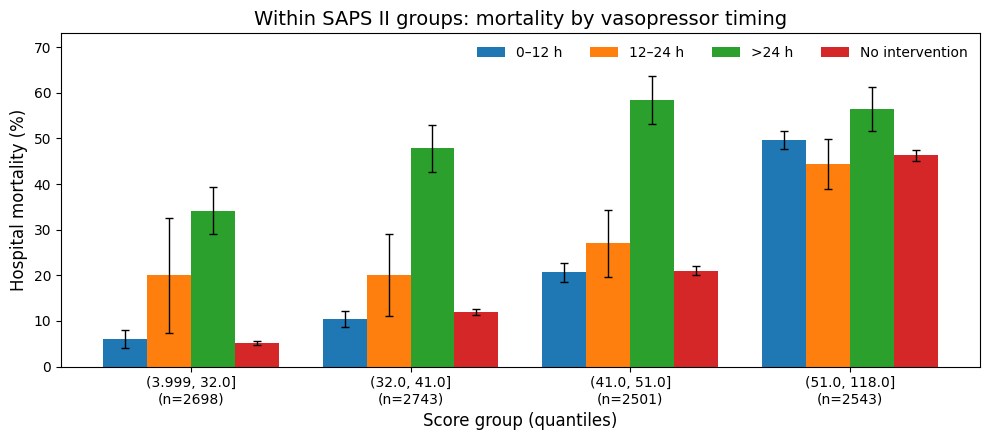

In [111]:
stats_renal_vaso = score_group_timing_stats(df4, "sofa_renal_bin", "vaso_timing")
plot_mortality_by_timing_within_score_bins(stats_renal_vaso, "sofa_renal_bin", "vaso_timing",
                                           "Within SOFA renal groups: mortality by vasopressor timing"); plt.show()

stats_saps_vaso = score_group_timing_stats(df4, "sapsii_bin", "vaso_timing")
plot_mortality_by_timing_within_score_bins(stats_saps_vaso, "sapsii_bin", "vaso_timing",
                                           "Within SAPS II groups: mortality by vasopressor timing"); plt.show()


In [112]:
import pandas as pd
import numpy as np
from src.db import q

def first_intervention_timing(
    df,
    patterns,
    label,
):
    """
    Adds two columns:
      - first_<label>_hours
      - first_<label>_timing  ∈ {0–12 h, 12–24 h, >24 h, No intervention}
    """

    where = " OR ".join([f"LOWER(di.label) LIKE '{p}'" for p in patterns])

    ev = q(f"""
        SELECT ie.icustay_id, ie.starttime
        FROM inputevents_mv ie
        JOIN d_items di ON ie.itemid = di.itemid
        WHERE {where}
    """)

    ev = ev.merge(
        df[["icustay_id", "intime"]],
        on="icustay_id",
        how="inner"
    ).dropna(subset=["starttime", "intime"])

    ev["hours_since_icu"] = (
        ev["starttime"] - ev["intime"]
    ).dt.total_seconds() / 3600

    ev = ev[ev["hours_since_icu"] >= 0]

    first_ev = (
        ev.sort_values(["icustay_id", "hours_since_icu"])
          .groupby("icustay_id", as_index=False)
          .first()[["icustay_id", "hours_since_icu"]]
    )

    out = df.merge(first_ev, on="icustay_id", how="left")

    timing_col = f"first_{label}_timing"
    hours_col = f"first_{label}_hours"

    out[hours_col] = out["hours_since_icu"]

    out[timing_col] = np.select(
        [
            out[hours_col].between(0, 12, inclusive="left"),
            out[hours_col].between(12, 24, inclusive="left"),
            out[hours_col] > 24,
            out[hours_col].isna(),
        ],
        [
            "0–12 h",
            "12–24 h",
            ">24 h",
            "No intervention",
        ],
        default="Other",
    )

    out[timing_col] = pd.Categorical(
        out[timing_col],
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

    return out.drop(columns=["hours_since_icu"])


In [113]:
# (entfernt: Fluid/Diuretic nach Score-Bins, nicht auf Folie)


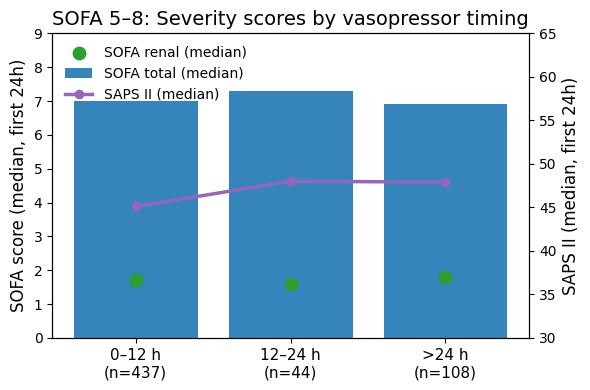

In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- DataFrame direkt aus deinen Werten
plot_df = pd.DataFrame({
    "Timing": ["0–12 h", "12–24 h", ">24 h"],
    "n": [437, 44, 108],
    "sofa_median": [7.0, 7.3, 6.9],
    "sofa_renal_median": [1.7, 1.6, 1.8],
    "sapsii_median": [45.1, 48.0, 47.9],
})

x = np.arange(len(plot_df))

fig, ax1 = plt.subplots(figsize=(6, 4))

# --- SOFA total (bars)
ax1.bar(
    x,
    plot_df["sofa_median"],
    color="#1f77b4",
    alpha=0.9,
    label="SOFA total (median)"
)

# --- SOFA renal (points)
ax1.scatter(
    x,
    plot_df["sofa_renal_median"],
    color="#2ca02c",
    s=80,
    zorder=3,
    label="SOFA renal (median)"
)

ax1.set_ylabel("SOFA score (median, first 24h)", fontsize=12)
ax1.set_ylim(0, 9)

# --- SAPS II (line, second axis)
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["sapsii_median"],
    color="#9467bd",
    marker="o",
    linewidth=2.5,
    label="SAPS II (median)"
)
ax2.set_ylabel("SAPS II (median, first 24h)", fontsize=12)
ax2.set_ylim(30, 65)

# --- x labels with n
ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{t}\n(n={n})" for t, n in zip(plot_df["Timing"], plot_df["n"])],
    fontsize=11
)

# --- title
ax1.set_title(
    "SOFA 5–8: Severity scores by vasopressor timing",
    fontsize=14
)

# --- combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()


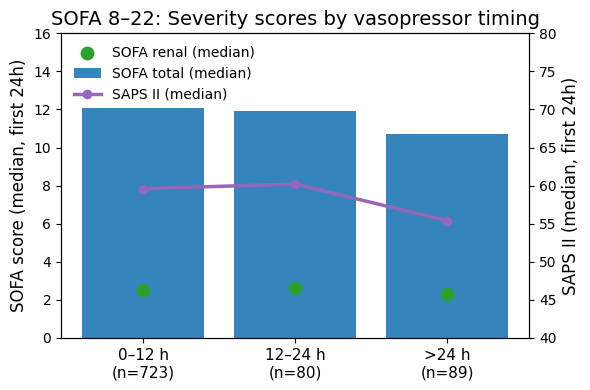

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Daten für SOFA 8–22
plot_df = pd.DataFrame({
    "Timing": ["0–12 h", "12–24 h", ">24 h"],
    "n": [723, 80, 89],
    "sofa_median": [12.1, 11.9, 10.7],
    "sofa_renal_median": [2.5, 2.6, 2.3],
    "sapsii_median": [59.6, 60.2, 55.4],
})

x = np.arange(len(plot_df))

fig, ax1 = plt.subplots(figsize=(6, 4))

# --- SOFA total (bars)
ax1.bar(
    x,
    plot_df["sofa_median"],
    color="#1f77b4",
    alpha=0.9,
    label="SOFA total (median)"
)

# --- SOFA renal (points)
ax1.scatter(
    x,
    plot_df["sofa_renal_median"],
    color="#2ca02c",
    s=80,
    zorder=3,
    label="SOFA renal (median)"
)

ax1.set_ylabel("SOFA score (median, first 24h)", fontsize=12)
ax1.set_ylim(0, 16)

# --- SAPS II (line, second axis)
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["sapsii_median"],
    color="#9467bd",
    marker="o",
    linewidth=2.5,
    label="SAPS II (median)"
)
ax2.set_ylabel("SAPS II (median, first 24h)", fontsize=12)
ax2.set_ylim(40, 80)

# --- x labels with n
ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{t}\n(n={n})" for t, n in zip(plot_df["Timing"], plot_df["n"])],
    fontsize=11
)

# --- title
ax1.set_title(
    "SOFA 8–22: Severity scores by vasopressor timing",
    fontsize=14
)

# --- combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [116]:
import numpy as np
import pandas as pd

df_test = df4.copy()

# Late vasopressor indicator
df_test["vaso_late"] = (
    df_test["vaso_timing"] == ">24 h"
).astype(int)

# Early (0–24 h) indicator
df_test["vaso_early"] = (
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])
).astype(int)


In [117]:
from scipy.stats import chi2_contingency, fisher_exact

def test_late_vs_early_by_score_bin(
    df,
    score_bin_col,
    outcome_col="hospital_mortality"
):
    results = []

    for b in df[score_bin_col].dropna().unique():
        sub = df[df[score_bin_col] == b]

        # only early vs late
        sub = sub[sub["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])]

        if sub.empty:
            continue

        table = pd.crosstab(
            sub["vaso_late"],
            sub[outcome_col]
        )

        # ensure 2x2
        if table.shape != (2, 2):
            continue

        n_late = table.loc[1].sum()
        n_early = table.loc[0].sum()

        mort_late = table.loc[1, 1] / n_late if n_late > 0 else np.nan
        mort_early = table.loc[0, 1] / n_early if n_early > 0 else np.nan

        # choose test
        if (table.values < 5).any():
            _, p = fisher_exact(table)
            test = "Fisher"
        else:
            _, p, _, _ = chi2_contingency(table)
            test = "Chi-square"

        results.append({
            "Score bin": str(b),
            "n early (≤24h)": n_early,
            "n late (>24h)": n_late,
            "Mortality early": mort_early * 100,
            "Mortality late": mort_late * 100,
            "Δ mortality (late−early)": (mort_late - mort_early) * 100,
            "p value": p,
            "Test": test,
        })

    return pd.DataFrame(results)


In [118]:
test_sofa_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sofa_bin"
)

test_sofa_vaso


,Score bin,n early (≤24h),n late (>24h),Mortality early,Mortality late,Δ mortality (late−early),p value,Test
0,"(5.0, 8.0]",481,108,16.424116,52.777778,36.353661,1.520401e-15,Chi-square
1,"(3.0, 5.0]",201,78,15.422886,50.000000,34.577114,5.713112e-09,Chi-square
2,"(-0.001, 3.0]",82,101,9.756098,41.584158,31.828061,3.514549e-06,Chi-square
3,"(8.0, 22.0]",803,89,44.209215,55.056180,10.846964,6.602299e-02,Chi-square


In [119]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests

def per_bin_effects(
    df,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    outcome_col="hospital_mortality",
    early_levels=("0–12 h", "12–24 h"),
    late_level=">24 h",
):
    rows = []

    bins = [b for b in df[score_bin_col].dropna().unique()]
    bins = sorted(bins, key=lambda x: str(x))

    for b in bins:
        sub = df[df[score_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(list(early_levels) + [late_level])].copy()
        if sub.empty:
            continue

        sub["late"] = (sub[timing_col] == late_level).astype(int)
        y = pd.to_numeric(sub[outcome_col], errors="coerce").astype("Int64")

        # 2x2 counts: rows late(1)/early(0), cols death(1)/survive(0)
        tab = pd.crosstab(sub["late"], y).reindex(index=[0,1], columns=[0,1], fill_value=0)

        # cells
        early_surv = int(tab.loc[0, 0]); early_death = int(tab.loc[0, 1])
        late_surv  = int(tab.loc[1, 0]); late_death  = int(tab.loc[1, 1])

        n_early = early_surv + early_death
        n_late  = late_surv + late_death
        if n_early == 0 or n_late == 0:
            continue

        risk_early = early_death / n_early
        risk_late  = late_death / n_late
        rd = risk_late - risk_early

        # Effect sizes + CI via Table2x2 (Woolf log-OR / log-RR; RD CI via normal approx not in Table2x2)
        t22 = Table2x2([[late_death, late_surv],[early_death, early_surv]])
        or_ = t22.oddsratio
        or_ci = t22.oddsratio_confint()     # 95% CI
        rr_ = t22.riskratio
        rr_ci = t22.riskratio_confint()

        # RD 95% CI (Newcombe-style is best; statsmodels has for 2 indep proportions)
        from statsmodels.stats.proportion import confint_proportions_2indep
        rd_ci = confint_proportions_2indep(
            late_death, n_late,
            early_death, n_early,
            method="newcomb"
        )

        # p-value: use Fisher if any expected <5 else chi-square
        chi2_ok = True
        try:
            _, p_chi, _, expected = chi2_contingency([[late_death, late_surv],[early_death, early_surv]])
            if (expected < 5).any():
                chi2_ok = False
        except:
            chi2_ok = False

        if chi2_ok:
            p = p_chi
            test = "Chi-square"
        else:
            _, p = fisher_exact([[late_death, late_surv],[early_death, early_surv]])
            test = "Fisher exact"

        rows.append({
            "Score bin": str(b),
            "early_death": early_death, "early_surv": early_surv, "n_early": n_early,
            "late_death": late_death, "late_surv": late_surv, "n_late": n_late,
            "risk_early_%": 100*risk_early,
            "risk_late_%": 100*risk_late,
            "RD_%": 100*rd,
            "RD_CI_low_%": 100*rd_ci[0],
            "RD_CI_high_%": 100*rd_ci[1],
            "RR": rr_, "RR_CI_low": rr_ci[0], "RR_CI_high": rr_ci[1],
            "OR": or_, "OR_CI_low": or_ci[0], "OR_CI_high": or_ci[1],
            "p": p,
            "test": test
        })

    res = pd.DataFrame(rows)

    # multiple-testing correction across bins (FDR/BH)
    if not res.empty:
        res["p_fdr_bh"] = multipletests(res["p"].values, method="fdr_bh")[1]

    # nice ordering for display
    return res.sort_values("Score bin").reset_index(drop=True)

res = per_bin_effects(df_test, score_bin_col="sofa_bin", timing_col="vaso_timing")
res


,Score bin,early_death,early_surv,n_early,late_death,late_surv,n_late,risk_early_%,risk_late_%,RD_%,...,RD_CI_high_%,RR,RR_CI_low,RR_CI_high,OR,OR_CI_low,OR_CI_high,p,test,p_fdr_bh
0,"(-0.001, 3.0]",8,74,82,42,59,101,9.756098,41.584158,31.828061,...,42.662439,4.262376,2.121539,8.563524,6.584746,2.871677,15.098799,3.514549e-06,Chi-square,4.686066e-06
1,"(3.0, 5.0]",31,170,201,39,39,78,15.422886,50.000000,34.577114,...,46.246673,3.241935,2.189495,4.800259,5.483871,3.051739,9.854329,5.713112e-09,Chi-square,1.142622e-08
2,"(5.0, 8.0]",79,402,481,57,51,108,16.424116,52.777778,36.353661,...,46.003167,3.213432,2.455050,4.206084,5.687267,3.632833,8.903523,1.520401e-15,Chi-square,6.081604e-15
3,"(8.0, 22.0]",355,448,803,49,40,89,44.209215,55.056180,10.846964,...,21.325140,1.245355,1.016399,1.525886,1.545915,0.995367,2.400979,6.602299e-02,Chi-square,6.602299e-02


In [122]:
test_renal_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sofa_renal_bin"
)

test_saps_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sapsii_bin"
)

test_renal_vaso, test_saps_vaso


(       Score bin  n early (≤24h)  n late (>24h)  Mortality early  \
 0     (2.0, 3.0]             268             56        41.791045   
 1  (-0.001, 1.0]             677            209        19.645495   
 2     (1.0, 2.0]             365             67        24.109589   
 3     (3.0, 4.0]             257             44        54.474708   
 
    Mortality late  Δ mortality (late−early)       p value        Test  
 0       44.642857                  2.851812  8.070907e-01  Chi-square  
 1       47.368421                 27.722926  3.306437e-15  Chi-square  
 2       52.238806                 28.129217  5.558790e-06  Chi-square  
 3       63.636364                  9.161655  3.337978e-01  Chi-square  ,
        Score bin  n early (≤24h)  n late (>24h)  Mortality early  \
 0  (51.0, 118.0]             698            108        48.997135   
 1  (3.999, 32.0]             160             85         6.875000   
 2   (41.0, 51.0]             410             89        21.219512   
 3   (32.0,

In [123]:
import statsmodels.formula.api as smf

# nur Patienten mit Vasopressoren
df_lr = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()

df_lr["vaso_late"] = (df_lr["vaso_timing"] == ">24 h").astype(int)

model = smf.logit(
    "hospital_mortality ~ vaso_late + sofa + vaso_late:sofa",
    data=df_lr
).fit()

model.summary()


Optimization terminated successfully.
         Current function value: 0.570069
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     hospital_mortality   No. Observations:                 1943
Model:                          Logit   Df Residuals:                     1939
Method:                           MLE   Df Model:                            3
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.1104
Time:                        15:39:30   Log-Likelihood:                -1107.6
converged:                       True   LL-Null:                       -1245.1
Covariance Type:            nonrobust   LLR p-value:                 2.618e-59
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.0194      0.177    -17.040      0.000      -3.367      -2.672
vaso_late          2.5973      0.281      9.248      0.000       2.047       3.148
sofa               0.2271      0.017     13.601      0.000       0.194       0.260
vaso_late:sofa    -0.1590      0.036     -4.437      0.000      -0.229      -0.089
==================================================================================
"""

In [124]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

def fmt_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def choose_test_2x2(tab):
    # tab is 2x2 numpy array [[a,b],[c,d]]
    try:
        _, p_chi, _, expected = chi2_contingency(tab)
        if (expected < 5).any():
            _, p = fisher_exact(tab)
            return p, "Fisher exact"
        return p_chi, "Chi-square"
    except Exception:
        _, p = fisher_exact(tab)
        return p, "Fisher exact"

def stratified_binary_outcome_table(df, score_bin_col, timing_col, group_a_levels, group_b_levels, outcome_col="hospital_mortality", label_a="A", label_b="B"):
    rows = []
    bins = df[score_bin_col].dropna().unique()
    bins = sorted(bins, key=lambda x: str(x))
    for b in bins:
        sub = df[df[score_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(list(group_a_levels) + list(group_b_levels))].copy()
        if sub.empty:
            continue
        sub["grp"] = np.where(sub[timing_col].isin(group_b_levels), "B", "A")
        y = pd.to_numeric(sub[outcome_col], errors="coerce").fillna(0).astype(int)
        n_a = int((sub["grp"] == "A").sum())
        n_b = int((sub["grp"] == "B").sum())
        if n_a == 0 or n_b == 0:
            continue
        deaths_a = int(y[sub["grp"] == "A"].sum())
        deaths_b = int(y[sub["grp"] == "B"].sum())
        mort_a = 100 * deaths_a / n_a
        mort_b = 100 * deaths_b / n_b
        delta = mort_b - mort_a
        alive_a = n_a - deaths_a
        alive_b = n_b - deaths_b
        tab = np.array([[alive_a, deaths_a], [alive_b, deaths_b]])
        p, test = choose_test_2x2(tab)
        rows.append({"Score bin": str(b), f"n {label_a}": n_a, f"n {label_b}": n_b, f"Mortality {label_a} (%)": mort_a, f"Mortality {label_b} (%)": mort_b, "Δ Mortality (pp)": delta, "p value": p, "Test": test})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    for col in out.columns:
        if "Mortality" in col or col == "Δ Mortality (pp)":
            out[col] = out[col].astype(float).round(1)
    out["p value"] = out["p value"].map(fmt_p)
    return out


In [128]:
tab_early_vs_late = stratified_binary_outcome_table(
    df_test,                       # oder df4/df3, solange sofa_bin + vaso_timing + hospital_mortality drin ist
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    group_a_levels=["0–12 h", "12–24 h"],   # Early
    group_b_levels=[">24 h"],              # Late
    label_a="Early (≤24h)",
    label_b="Late (>24h)",
)

tab_early_vs_late


NameError: name 'stratified_binary_outcome_table' is not defined

In [ ]:
tab_late_vs_never = stratified_binary_outcome_table(
    df_test,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    group_a_levels=["No intervention"],
    group_b_levels=[">24 h"],
    label_a="Never",
    label_b="Late (>24h)",
)

tab_late_vs_never


NameError: name 'stratified_binary_outcome_table' is not defined

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

def sofa_renal_late_vs_never(
    df,
    renal_bin_col="sofa_renal_bin",
    timing_col="vaso_timing",
    outcome_col="hospital_mortality",
):
    rows = []

    bins = sorted(df[renal_bin_col].dropna().unique(), key=lambda x: str(x))

    for b in bins:
        sub = df[df[renal_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(["No intervention", ">24 h"])].copy()
        if sub.empty:
            continue

        sub["grp"] = np.where(sub[timing_col] == ">24 h", "Late", "Never")
        y = pd.to_numeric(sub[outcome_col], errors="coerce").fillna(0).astype(int)

        n_never = int((sub["grp"] == "Never").sum())
        n_late  = int((sub["grp"] == "Late").sum())
        if n_never == 0 or n_late == 0:
            continue

        d_never = int(y[sub["grp"] == "Never"].sum())
        d_late  = int(y[sub["grp"] == "Late"].sum())

        mort_never = 100 * d_never / n_never
        mort_late  = 100 * d_late  / n_late
        delta = mort_late - mort_never

        # 2x2 table: rows Never/Late, cols Alive/Dead
        tab = np.array([
            [n_never - d_never, d_never],
            [n_late  - d_late,  d_late],
        ])

        # automatic test choice
        try:
            _, p_chi, _, exp = chi2_contingency(tab)
            if (exp < 5).any():
                _, p = fisher_exact(tab)
                test = "Fisher exact"
            else:
                p = p_chi
                test = "Chi-square"
        except:
            _, p = fisher_exact(tab)
            test = "Fisher exact"

        rows.append({
            "SOFA renal score bin": str(b),
            "Never n": n_never,
            "Late n": n_late,
            "Mortality Never (%)": round(mort_never, 1),
            "Mortality Late (%)": round(mort_late, 1),
            "Δ Mortality (pp)": round(delta, 1),
            "p value": "<0.001" if p < 0.001 else f"{p:.3f}",
            "Test": test,
        })

    return pd.DataFrame(rows)


In [ ]:
tab_renal_late_vs_never = sofa_renal_late_vs_never(df_test)
tab_renal_late_vs_never


In [ ]:
import statsmodels.formula.api as smf

df_simple = df_test[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])
].copy()

df_simple["vaso_late"] = (df_simple["vaso_timing"] == ">24 h").astype(int)

model_simple = smf.logit(
    "hospital_mortality ~ vaso_late + sofa",
    data=df_simple
).fit()

model_simple.summary()


In [ ]:
import statsmodels.formula.api as smf

# nur Late vs Never
df_late_never = df_test[
    df_test["vaso_timing"].isin([">24 h", "No intervention"])
].copy()

# Binary indicator: Late = 1, Never = 0
df_late_never["vaso_late"] = (df_late_never["vaso_timing"] == ">24 h").astype(int)

model_late_vs_never = smf.logit(
    "hospital_mortality ~ vaso_late + sofa",
    data=df_late_never
).fit()

model_late_vs_never.summary()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SOFA range
sofa_vals = np.arange(0, 20)

# design matrix
pred_df = pd.DataFrame({
    "sofa": np.tile(sofa_vals, 2),
    "vaso_late": np.repeat([0, 1], len(sofa_vals)),
})

# predict probabilities
pred_df["mortality"] = model_simple.predict(pred_df)

# plot
plt.figure(figsize=(7,5))
for k, g in pred_df.groupby("vaso_late"):
    label = "Early (≤24 h)" if k == 0 else "Late (>24 h)"
    plt.plot(g["sofa"], 100*g["mortality"], label=label, linewidth=3)

plt.xlabel("SOFA score (first 24h)")
plt.ylabel("Predicted hospital mortality (%)")
plt.title("Adjusted mortality by vasopressor timing")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
pred_df2 = pd.DataFrame({
    "sofa": np.tile(sofa_vals, 2),
    "vaso_late": np.repeat([0, 1], len(sofa_vals)),
})

pred_df2["mortality"] = model_late_vs_never.predict(pred_df2)

plt.figure(figsize=(7,5))
for k, g in pred_df2.groupby("vaso_late"):
    label = "Never" if k == 0 else "Late (>24 h)"
    plt.plot(g["sofa"], 100*g["mortality"], label=label, linewidth=3)

plt.xlabel("SOFA score (first 24h)")
plt.ylabel("Predicted hospital mortality (%)")
plt.title("Adjusted mortality: late vs never vasopressors")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Late vs Early (≤24h) subset
df_evle = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()
df_evle["vaso_late"] = (df_evle["vaso_timing"] == ">24 h").astype(int)

# keep only valid mortality
df_evle["hospital_mortality"] = pd.to_numeric(df_evle["hospital_mortality"], errors="coerce")
df_evle = df_evle.dropna(subset=["hospital_mortality", "sofa"])
df_evle["hospital_mortality"] = df_evle["hospital_mortality"].astype(int)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)


In [ ]:
# (entfernt: Effect Modification – nicht für Präsentation)
